# P3.3 – Knowledge Distillation

Pruning (Notebook 2) reduced the model's size and speed but caused an accuracy drop.
**Knowledge Distillation (KD)** recovers that loss by training the pruned model (student)
to mimic the original model's (teacher's) output distribution — not just its hard labels.

The key insight: the teacher's **soft probabilities** carry more signal than one-hot labels.
A sentence classified as 80% positive / 15% neutral / 5% negative tells the student much more
than simply "positive".

**KD loss:**
$$\mathcal{L}_{KD} = \alpha \cdot T^2 \cdot \text{KL}\!\left(\sigma\!\left(\frac{z_s}{T}\right) \| \sigma\!\left(\frac{z_t}{T}\right)\right) + (1-\alpha) \cdot \text{CE}(z_s, y)$$

- $z_t, z_s$ — teacher / student logits
- $T$ — temperature (higher = softer distributions)
- $\alpha$ — weight between soft and hard loss

> **Prerequisites:** Run Notebooks 1 and 2 first to generate `data_splits.pkl`,
> `baseline_results.json`, `pruning_results.json`, and `student_model/`.


---
**Author:** Adebanji Oluwatimileyin Adelowo  
**GitHub:** [adebanjiadelowo](https://github.com/adebanjiadelowo)

In [1]:
import os
import copy
import json
import time
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

try:
    import google.colab
    BASE_DIR = '/content/financial-sentiment-distillation/'
except ImportError:
    import os
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.makedirs(BASE_DIR, exist_ok=True)
print('Working dir:', BASE_DIR)
os.makedirs(BASE_DIR, exist_ok=True)
print('Working dir:', BASE_DIR)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cpu
Working dir: /Users/adebanjiadelowo/Documents/GitHub/llm-portfolio/01-financial-sentiment-distillation
Working dir: /Users/adebanjiadelowo/Documents/GitHub/llm-portfolio/01-financial-sentiment-distillation


## 1 – Load teacher, student, data, and previous results

In [2]:
MODEL_NAME   = 'ProsusAI/finbert'
STUDENT_DIR  = os.path.join(BASE_DIR, 'student_model')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Teacher = original FinBERT (frozen during distillation)
teacher = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

# Student = pruned model from Notebook 2
student = AutoModelForSequenceClassification.from_pretrained(STUDENT_DIR).to(DEVICE)

print('Teacher layers:', teacher.config.num_hidden_layers)
print('Student layers:', student.config.num_hidden_layers)
print('Teacher params: {:.1f}M'.format(sum(p.numel() for p in teacher.parameters()) / 1e6))
print('Student params: {:.1f}M'.format(sum(p.numel() for p in student.parameters()) / 1e6))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Teacher layers: 12
Student layers: 9
Teacher params: 109.5M
Student params: 88.2M


In [3]:
with open(os.path.join(BASE_DIR, 'data_splits.pkl'), 'rb') as f:
    splits = pickle.load(f)
with open(os.path.join(BASE_DIR, 'baseline_results.json')) as f:
    baseline = json.load(f)
with open(os.path.join(BASE_DIR, 'pruning_results.json')) as f:
    pruning = json.load(f)

train_texts  = splits['train_texts']
train_labels = splits['train_labels']
test_texts   = splits['test_texts']
test_labels  = splits['test_labels']
id2label     = splits['id2label']

print('Train: {}  Test: {}'.format(len(train_texts), len(test_texts)))

Train: 1811  Test: 453


## 2 – DataLoader for training

In [4]:
from torch.utils.data import Dataset, DataLoader


class FinancialSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


# Adaptive batch size: larger on CPU to reduce number of steps
BATCH_SIZE = 32 if DEVICE == 'cpu' else 16

# shuffle=False so teacher-logit cache stays aligned with DataLoader order
train_dataset = FinancialSentimentDataset(train_texts, train_labels, tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Train batches  :', len(train_loader))
print('Batch size     :', BATCH_SIZE, '(adaptive)')
print('Shuffle        : False (required for teacher-logit caching)')

Train batches  : 57
Batch size     : 32 (adaptive)
Shuffle        : False (required for teacher-logit caching)


## 3 – Knowledge Distillation loss

The combined loss blends:
- **Soft loss** — KL divergence between teacher and student soft probabilities (temperature-scaled)
- **Hard loss** — standard cross-entropy with true labels

In [5]:
def distillation_loss(student_logits, teacher_logits, true_labels, T=3.0, alpha=0.7):
    """
    T     : temperature — higher values soften the teacher distribution
    alpha : weight on the soft (KD) loss; (1-alpha) goes to hard (CE) loss
    """
    soft_student = F.log_softmax(student_logits / T, dim=-1)
    soft_teacher = F.softmax(teacher_logits  / T, dim=-1)

    kd_loss   = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T ** 2)
    ce_loss   = F.cross_entropy(student_logits, true_labels)

    return alpha * kd_loss + (1.0 - alpha) * ce_loss


print('Distillation loss function ready.  T=3, alpha=0.7')

Distillation loss function ready.  T=3, alpha=0.7


## 4 – Training loop

In [6]:
def get_model_size_mb(model, tmp_dir='/tmp/p3_kd_size'):
    if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir)
    model.save_pretrained(tmp_dir)
    total = sum(
        os.path.getsize(os.path.join(tmp_dir, fn))
        for fn in os.listdir(tmp_dir)
        if os.path.isfile(os.path.join(tmp_dir, fn))
    )
    shutil.rmtree(tmp_dir)
    return total / (1024 ** 2)


def benchmark_model(model, tokenizer, texts, labels, batch_size=16, label='model'):
    model.eval()
    all_preds = []
    t0 = time.time()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            inp = tokenizer(texts[i:i + batch_size], return_tensors='pt',
                            padding=True, truncation=True, max_length=128)
            inp = {k: v.to(DEVICE) for k, v in inp.items()}
            all_preds.extend(model(**inp).logits.argmax(-1).cpu().tolist())
    elapsed = time.time() - t0
    return {
        'label':         label,
        'accuracy':      round(accuracy_score(labels, all_preds), 4),
        'f1_weighted':   round(f1_score(labels, all_preds, average='weighted'), 4),
        'params_M':      round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
        'size_mb':       round(get_model_size_mb(model), 2),
        'ms_per_sample': round(elapsed * 1000 / len(texts), 3),
        'predictions':   all_preds,
    }

In [7]:
# Adaptive hyperparameters — 1 epoch on CPU is enough to verify distillation works
N_EPOCHS = 1 if DEVICE == 'cpu' else 3
LR       = 2e-5
T        = 3.0
ALPHA    = 0.7

# Pre-compute teacher logits once — eliminates teacher forward pass from the training loop
print('Pre-computing teacher logits ...')
teacher_logits_cache = []
teacher.eval()
with torch.no_grad():
    for i in range(0, len(train_texts), BATCH_SIZE):
        inp = tokenizer(
            train_texts[i:i + BATCH_SIZE],
            return_tensors='pt', padding=True, truncation=True, max_length=128
        )
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        teacher_logits_cache.append(teacher(**inp).logits.cpu())
print('Cached {} teacher logit tensors.'.format(len(teacher_logits_cache)))

optimizer = AdamW(student.parameters(), lr=LR, weight_decay=0.01)
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1,
                     total_iters=N_EPOCHS * len(train_loader))

history = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_f1': []}
print('Starting KD ({} epoch(s), batch={}, T={}, alpha={})'.format(
    N_EPOCHS, BATCH_SIZE, T, ALPHA))
print('Student: {} layers  |  Teacher: {} layers'.format(
    student.config.num_hidden_layers, teacher.config.num_hidden_layers))
print('-' * 60)

for epoch in range(N_EPOCHS):
    student.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)
        true_labels = batch['labels'].to(DEVICE)

        # Use cached teacher logits (no teacher forward pass needed)
        t_logits = teacher_logits_cache[batch_idx].to(DEVICE)

        s_kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
        if token_type_ids is not None:
            s_kwargs['token_type_ids'] = token_type_ids
        student_logits = student(**s_kwargs).logits

        loss = distillation_loss(student_logits, t_logits, true_labels, T=T, alpha=ALPHA)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val = benchmark_model(student, tokenizer, test_texts, test_labels)

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(round(avg_loss, 4))
    history['val_acc'].append(val['accuracy'])
    history['val_f1'].append(val['f1_weighted'])

    print('Epoch {:2d}/{} | Loss: {:.4f} | Acc: {:.2f}% | F1: {:.4f}'.format(
        epoch + 1, N_EPOCHS, avg_loss, val['accuracy'] * 100, val['f1_weighted']))

print('\nDistillation complete.')

Pre-computing teacher logits ...
Cached 57 teacher logit tensors.
Starting KD (1 epoch(s), batch=32, T=3.0, alpha=0.7)
Student: 9 layers  |  Teacher: 12 layers
------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch  1/1 | Loss: 0.3703 | Acc: 96.91% | F1: 0.9691

Distillation complete.


## 5 – Training curves

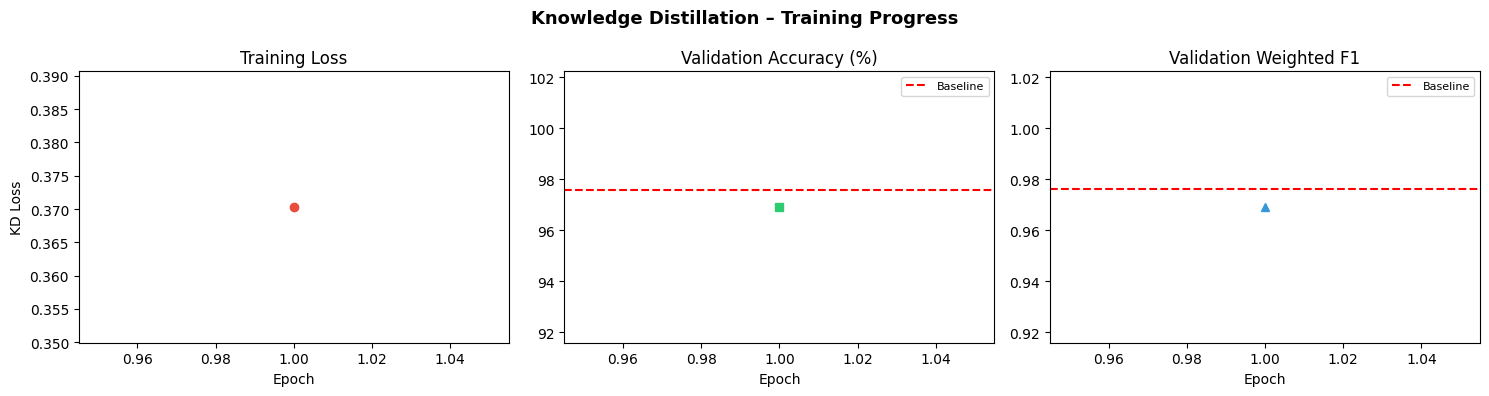

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['epoch'], history['train_loss'], 'o-', color='#e74c3c')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('KD Loss')

axes[1].plot(history['epoch'], [a * 100 for a in history['val_acc']], 's-', color='#2ecc71')
axes[1].axhline(baseline['accuracy'] * 100, color='red', linestyle='--', label='Baseline')
axes[1].set_title('Validation Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)

axes[2].plot(history['epoch'], history['val_f1'], '^-', color='#3498db')
axes[2].axhline(baseline['f1_weighted'], color='red', linestyle='--', label='Baseline')
axes[2].set_title('Validation Weighted F1')
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=8)

plt.suptitle('Knowledge Distillation – Training Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'kd_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6 – Final benchmark: distilled student

In [9]:
print('Final benchmark of distilled student ...')
result_distilled = benchmark_model(
    student, tokenizer, test_texts, test_labels,
    label='Distilled Student'
)

print('\n=== Distilled Student Results ===')
for k, v in result_distilled.items():
    if k != 'predictions':
        print('  {:20s}: {}'.format(k, v))

Final benchmark of distilled student ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Distilled Student Results ===
  label               : Distilled Student
  accuracy            : 0.9691
  f1_weighted         : 0.9691
  params_M            : 88.22
  size_mb             : 336.55
  ms_per_sample       : 13.382


In [10]:
print(classification_report(
    test_labels, result_distilled['predictions'],
    target_names=[id2label[i] for i in range(3)]
))

              precision    recall  f1-score   support

    positive       0.95      0.94      0.94       114
    negative       0.94      1.00      0.97        61
     neutral       0.99      0.97      0.98       278

    accuracy                           0.97       453
   macro avg       0.96      0.97      0.96       453
weighted avg       0.97      0.97      0.97       453



## 7 – Full pipeline comparison

The final comparison across all four model versions in the project.

In [11]:
summary = [
    {'label': 'Baseline',          **{k: baseline[k]                     for k in ['accuracy', 'f1_weighted', 'params_M', 'size_mb', 'ms_per_sample']}},
    {'label': 'Head Pruned',       **{k: pruning['head_pruned'][k]        for k in ['accuracy', 'f1_weighted', 'params_M', 'size_mb', 'ms_per_sample']}},
    {'label': 'Layer Dropped',     **{k: pruning['layer_dropped'][k]      for k in ['accuracy', 'f1_weighted', 'params_M', 'size_mb', 'ms_per_sample']}},
    {'label': 'Distilled Student', **{k: result_distilled[k]              for k in ['accuracy', 'f1_weighted', 'params_M', 'size_mb', 'ms_per_sample']}},
]

print('{:<22} {:>10} {:>10} {:>12} {:>10} {:>14}'.format(
    'Model', 'Accuracy', 'F1', 'Params (M)', 'Size (MB)', 'Speed (ms)'))
print('-' * 80)
for r in summary:
    print('{:<22} {:>10.2f}% {:>10.4f} {:>12.2f} {:>10.2f} {:>14.3f}'.format(
        r['label'], r['accuracy'] * 100, r['f1_weighted'],
        r['params_M'], r['size_mb'], r['ms_per_sample']
    ))

Model                    Accuracy         F1   Params (M)  Size (MB)     Speed (ms)
--------------------------------------------------------------------------------
Baseline                    97.57%     0.9761       109.48     417.67         15.345
Head Pruned                 95.36%     0.9530       109.48     417.67         13.272
Layer Dropped               61.81%     0.4804        88.22     336.55          9.320
Distilled Student           96.91%     0.9691        88.22     336.55         13.382


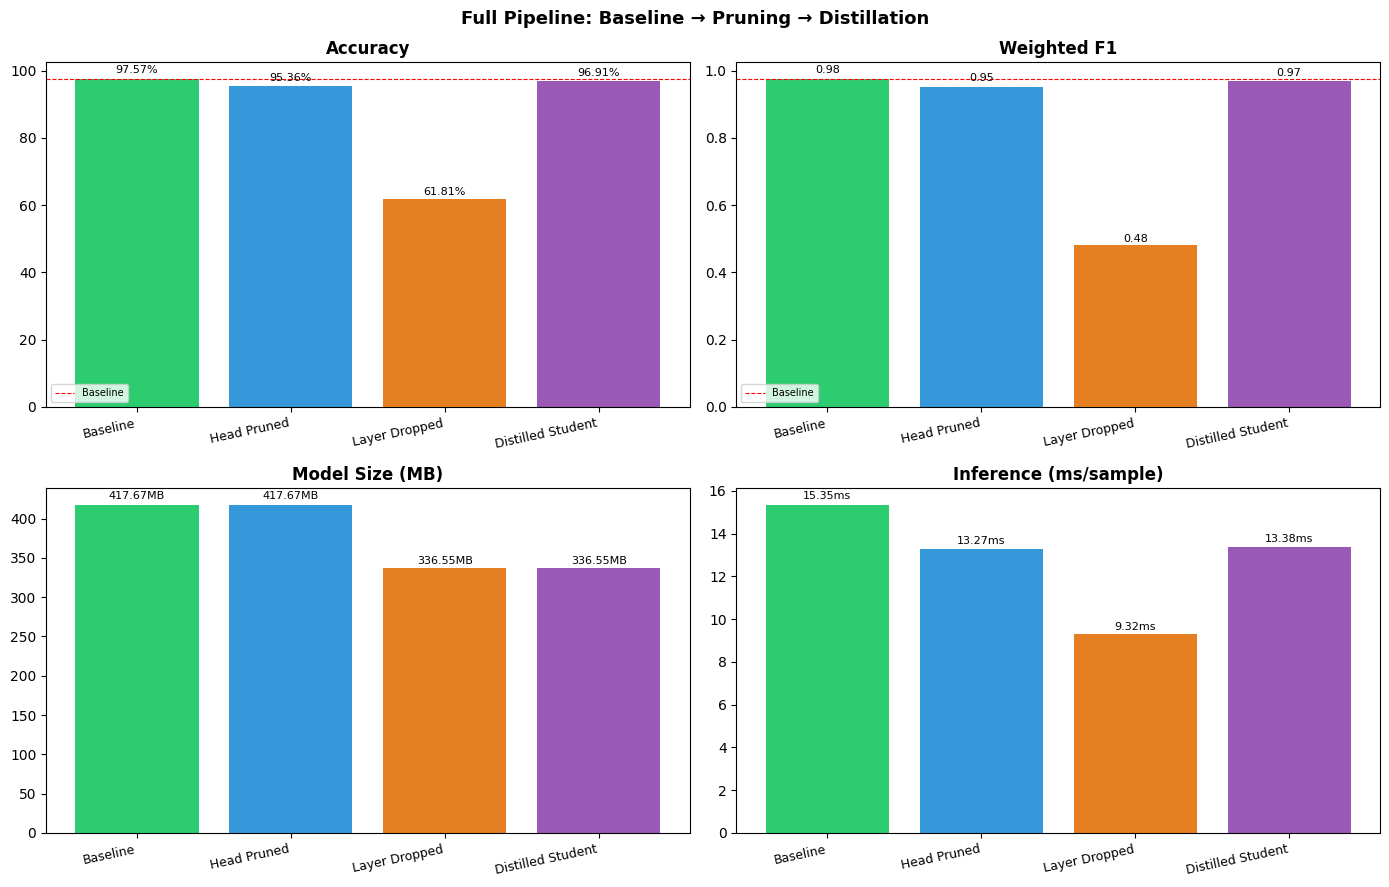

In [12]:
labels_s = [r['label'] for r in summary]
colors   = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']

metrics_plot = [
    ('accuracy',      'Accuracy',             True,  '%'),
    ('f1_weighted',   'Weighted F1',          True,  ''),
    ('size_mb',       'Model Size (MB)',      False, 'MB'),
    ('ms_per_sample', 'Inference (ms/sample)', False, 'ms'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (metric, title, higher_better, unit) in zip(axes.flat, metrics_plot):
    vals = [r[metric] * (100 if unit == '%' else 1) for r in summary]
    bars = ax.bar(range(len(labels_s)), vals, color=colors)
    ax.set_xticks(range(len(labels_s)))
    ax.set_xticklabels(labels_s, rotation=12, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                '{:.2f}{}'.format(val, unit),
                ha='center', va='bottom', fontsize=8)
    if higher_better:
        ax.axhline(vals[0], color='red', linestyle='--', linewidth=0.8, label='Baseline')
        ax.legend(fontsize=7)

plt.suptitle('Full Pipeline: Baseline → Pruning → Distillation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'full_pipeline_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8 – Save the final distilled model

In [13]:
DISTILLED_DIR = os.path.join(BASE_DIR, 'distilled_model')
if os.path.exists(DISTILLED_DIR): shutil.rmtree(DISTILLED_DIR)
student.save_pretrained(DISTILLED_DIR)
tokenizer.save_pretrained(DISTILLED_DIR)

kd_results = {k: v for k, v in result_distilled.items() if k != 'predictions'}
with open(os.path.join(BASE_DIR, 'kd_results.json'), 'w') as f:
    json.dump(kd_results, f, indent=2)

print('Saved distilled model to:', DISTILLED_DIR)
print('Saved', os.path.join(BASE_DIR, 'kd_results.json'))

# Recovery summary
pruned_acc = pruning['layer_dropped']['accuracy']
print('\n=== Performance Recovery ===')
print('  Baseline accuracy     : {:.2f}%'.format(baseline['accuracy'] * 100))
print('  After pruning         : {:.2f}% ({:+.2f}pp)'.format(
    pruned_acc * 100, (pruned_acc - baseline['accuracy']) * 100))
print('  After distillation    : {:.2f}% ({:+.2f}pp vs pruned)'.format(
    result_distilled['accuracy'] * 100,
    (result_distilled['accuracy'] - pruned_acc) * 100))
print('  Size reduction        : {:.1f}% ({} MB → {} MB)'.format(
    (1 - result_distilled['size_mb'] / baseline['size_mb']) * 100,
    baseline['size_mb'], result_distilled['size_mb']))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved distilled model to: /Users/adebanjiadelowo/Documents/GitHub/llm-portfolio/01-financial-sentiment-distillation/distilled_model
Saved /Users/adebanjiadelowo/Documents/GitHub/llm-portfolio/01-financial-sentiment-distillation/kd_results.json

=== Performance Recovery ===
  Baseline accuracy     : 97.57%
  After pruning         : 61.81% (-35.76pp)
  After distillation    : 96.91% (+35.10pp vs pruned)
  Size reduction        : 19.4% (417.67 MB → 336.55 MB)


## 9 – Quick-start inference with the distilled model

In [14]:
def predict_sentiment(texts, model, tokenizer, id2label):
    model.eval()
    inputs = tokenizer(texts, return_tensors='pt', padding=True,
                       truncation=True, max_length=128)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits, dim=-1).cpu().numpy()
    preds = probs.argmax(axis=-1)

    results = []
    for i, text in enumerate(texts):
        results.append({
            'text':      text[:80] + '...' if len(text) > 80 else text,
            'sentiment': id2label[preds[i]],
            'confidence': round(float(probs[i].max()), 3),
            'scores': {id2label[j]: round(float(probs[i][j]), 3) for j in range(3)},
        })
    return results


test_sentences = [
    'The company reported record-breaking profits for the third consecutive quarter.',
    'Shares fell sharply after the CEO announced unexpected restructuring charges.',
    'Revenue remained flat compared to the same period last year.',
    'The merger is expected to create significant synergies and long-term value for shareholders.',
    'Regulators launched an investigation into the firm over alleged accounting irregularities.',
]

results = predict_sentiment(test_sentences, student, tokenizer, id2label)

print('=== Distilled Model Inference Demo ===')
print()
for r in results:
    print('Text      : {}'.format(r['text']))
    print('Sentiment : {}  (confidence: {})'.format(r['sentiment'], r['confidence']))
    print('Scores    : {}'.format(r['scores']))
    print()

=== Distilled Model Inference Demo ===

Text      : The company reported record-breaking profits for the third consecutive quarter.
Sentiment : positive  (confidence: 0.923)
Scores    : {'positive': 0.923, 'negative': 0.029, 'neutral': 0.048}

Text      : Shares fell sharply after the CEO announced unexpected restructuring charges.
Sentiment : negative  (confidence: 0.957)
Scores    : {'positive': 0.019, 'negative': 0.957, 'neutral': 0.024}

Text      : Revenue remained flat compared to the same period last year.
Sentiment : negative  (confidence: 0.914)
Scores    : {'positive': 0.058, 'negative': 0.914, 'neutral': 0.028}

Text      : The merger is expected to create significant synergies and long-term value for s...
Sentiment : positive  (confidence: 0.835)
Scores    : {'positive': 0.835, 'negative': 0.011, 'neutral': 0.154}

Text      : Regulators launched an investigation into the firm over alleged accounting irreg...
Sentiment : neutral  (confidence: 0.487)
Scores    : {'positive':